**Main Cryptojacking Detection Notebook**

Classify and explain the results of the cryptojacking detection model.

In [4]:
# Constant Values for Configuration
from pathlib import Path

SAMPLE_PATH = r"D:\\BSCS\\Cryptojacking Detection Thesis\\Data Collection V2\\graph_aware_classifier\\dataset\\benign\\example2.exe.json"
NGRAM_SIZE = 2

SHAP_TOP_FEATURES = 20
OCCURENCES_LOOKUP = str(
    Path(SAMPLE_PATH).resolve().parents[2]
    / "occurences"
    / f"{Path(SAMPLE_PATH).stem}_vocabulary.json"
)

In [5]:
from pathlib import Path
import importlib
import sys

project_root = Path.cwd()
if project_root.name == "graph_aware_classifier":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from graph_aware_classifier.sample_transformer import transform_sample
import graph_aware_classifier.sample_explainer as sample_explainer

sample_explainer = importlib.reload(sample_explainer)
explain_sample = sample_explainer.explain_sample
ranked_feature_contributions = sample_explainer.ranked_feature_contributions

transformed_sample = transform_sample(
    sample_path=SAMPLE_PATH,
    ngram_size=NGRAM_SIZE,
)

explanation, prediction = explain_sample(
    ngram_size=NGRAM_SIZE,
    transformed_sample=transformed_sample,
)

top_features = ranked_feature_contributions(
    explanation,
    limit=SHAP_TOP_FEATURES,
)


print(top_features)

[{'feature_id': 3601, 'ngram': 'CALL PUSH', 'value': 0.012283943593502045, 'shap_value': 0.00841745724423548}, {'feature_id': 3600, 'ngram': 'SUB PUSH', 'value': 0.003913468681275845, 'shap_value': 0.007701325742932631}, {'feature_id': 3625, 'ngram': 'POP PUSH', 'value': 0.013126426376402378, 'shap_value': 0.007338136970398709}, {'feature_id': 3688, 'ngram': 'POP LEA', 'value': 8.15305975265801e-05, 'shap_value': 0.0064899610282638754}, {'feature_id': 3604, 'ngram': 'ADD PUSH', 'value': 0.009049897082149982, 'shap_value': 0.006439542836990121}, {'feature_id': 4259, 'ngram': 'FST MOV', 'value': 5.435373532236554e-05, 'shap_value': -0.006128501141981101}, {'feature_id': 1969, 'ngram': 'CALL RET', 'value': 0.00046200674842111766, 'shap_value': 0.005979843859705892}, {'feature_id': 8178, 'ngram': 'STOSD.REP FNSTENV', 'value': 8.15305975265801e-05, 'shap_value': -0.005969723407250151}, {'feature_id': 3720, 'ngram': 'SBB INC', 'value': 8.15305975265801e-05, 'shap_value': 0.005910696757340432

---------------------------------------------
- RF Prediction
---------------------------------------------
Class: 0
Label: Benign
---------------------------------------------

DECISION TREE RULES (Tree 0, depth-limited view)
|--- BSWAP LEA <= 0.000000
|   |--- LEA NOP <= 0.000393
|   |   |--- CALL PUSH <= 0.000002
|   |   |   |--- cmn mov <= 0.000001
|   |   |   |   |--- add add <= 0.000012
|   |   |   |   |   |--- truncated branch of depth 22
|   |   |   |   |--- add add >  0.000012
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- cmn mov >  0.000001
|   |   |   |   |--- st4 strb <= 0.000007
|   |   |   |   |   |--- weights: [0.000000, 55.000000] class: 1.0
|   |   |   |   |--- st4 strb >  0.000007
|   |   |   |   |   |--- weights: [1.000000, 0.000000] class: 0.0
|   |   |--- CALL PUSH >  0.000002
|   |   |   |--- ADDSD ADDPD <= 0.000001
|   |   |   |   |--- POP STMXCSR <= 0.000010
|   |   |   |   |   |--- truncated branch of depth 9
|   |   |   |   |--- POP STM

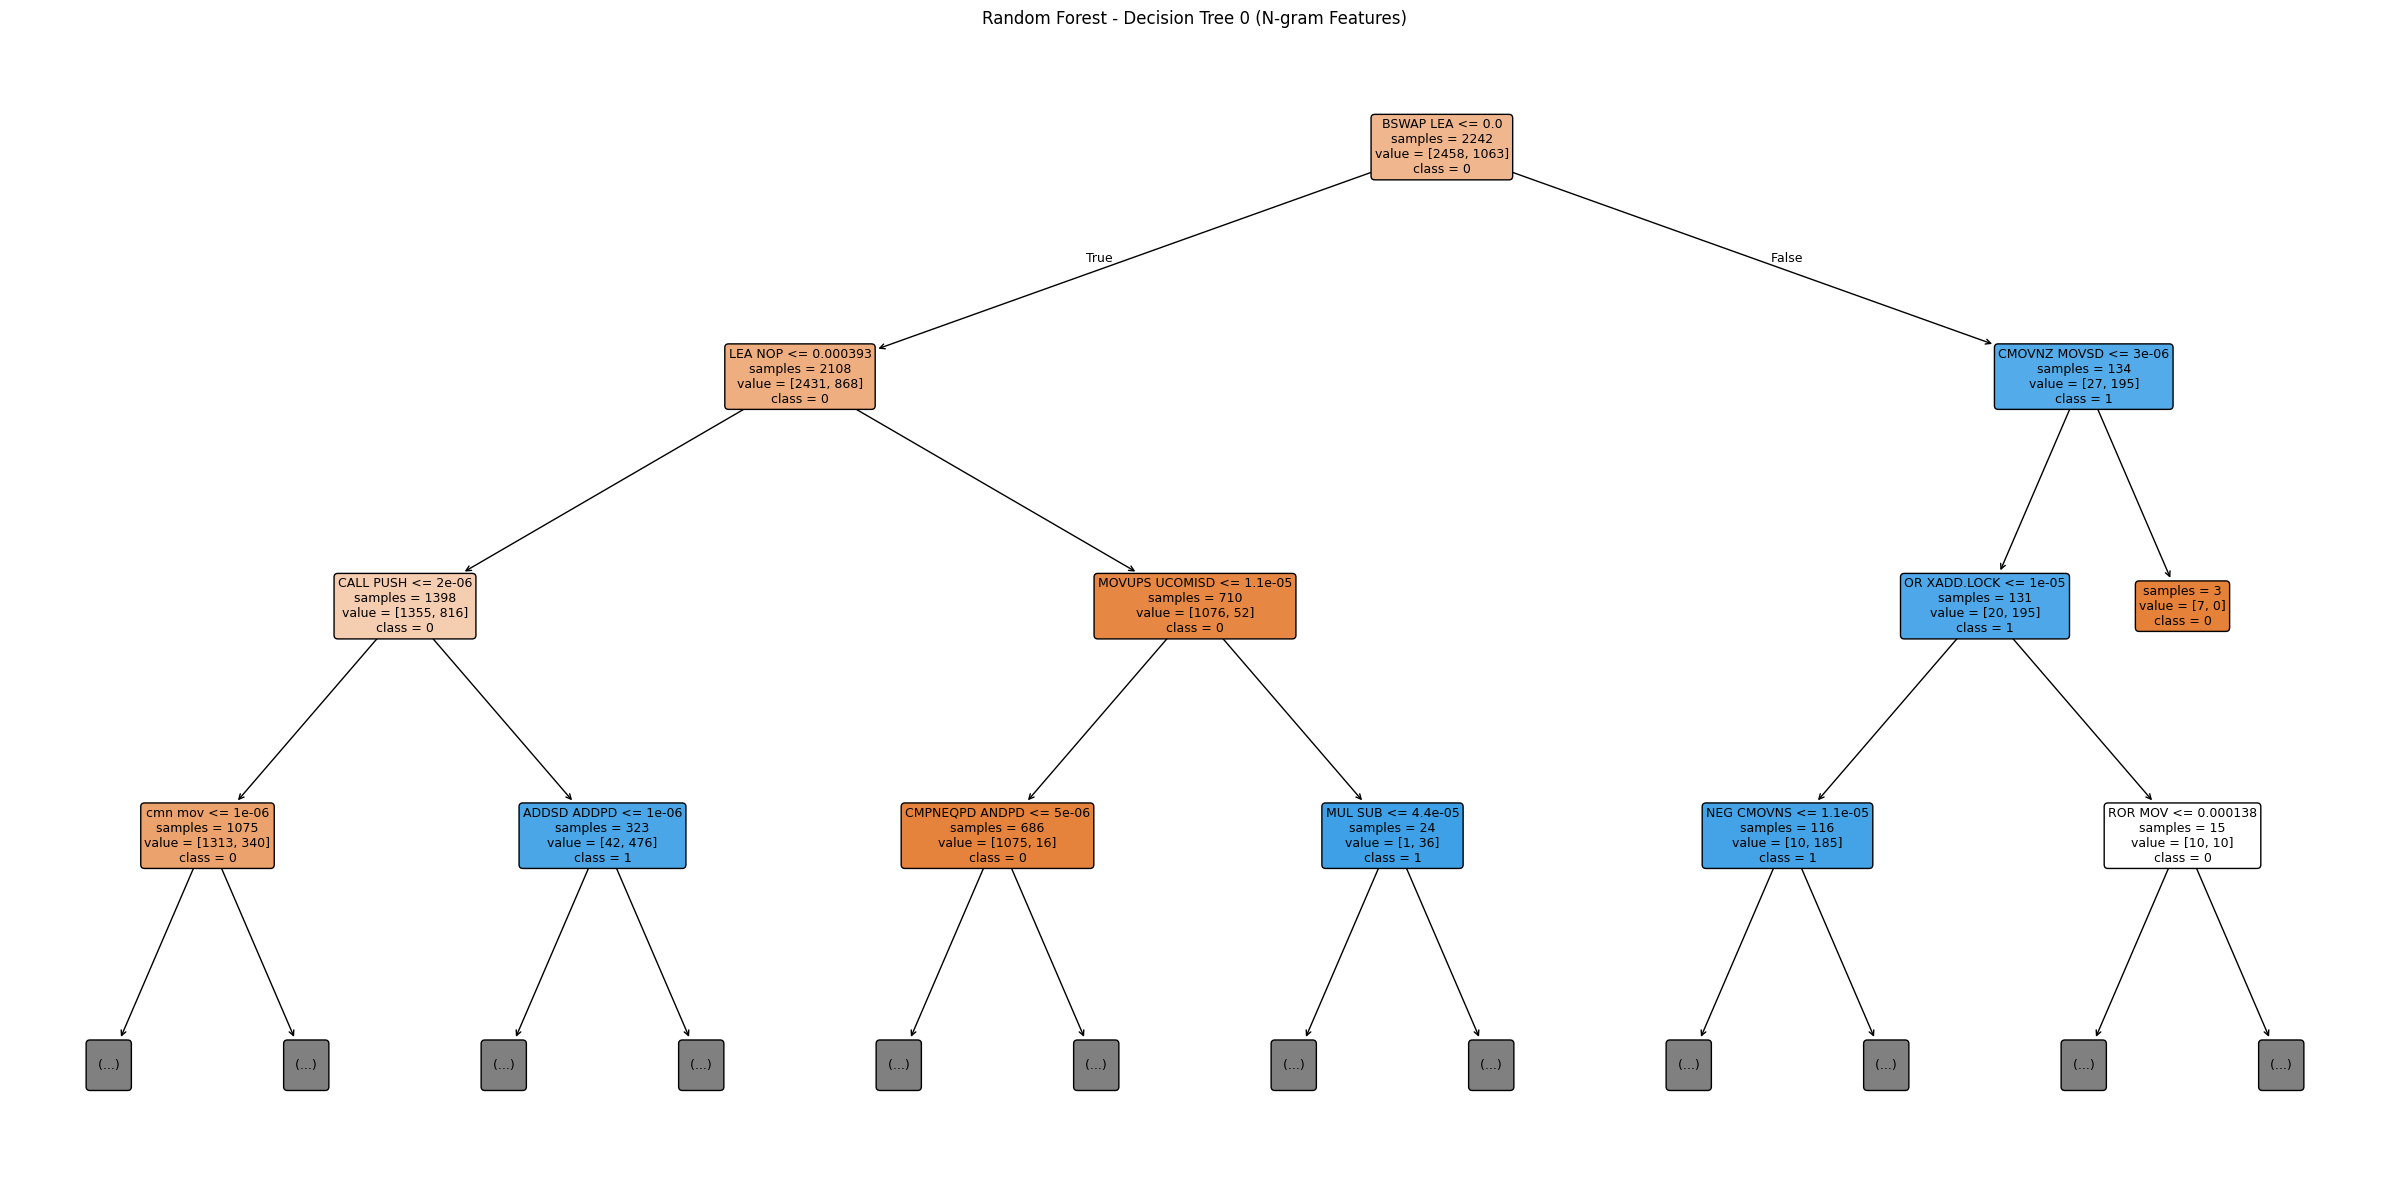

In [23]:
#############################################
# Display RF Prediction and SHAP Explanation
#############################################

import pandas as pd
from IPython.display import display

print("---------------------------------------------")
print("- RF Prediction")
print("---------------------------------------------")

predicted_class = int(prediction[0])
class_name = {
    0: "Benign",
    1: "Cryptojacking",
}.get(predicted_class, "Unknown")

print(f"Class: {predicted_class}")
print(f"Label: {class_name}")
print("---------------------------------------------")

# Visualize one forest tree with ngrams instead of feature indices.
import matplotlib.pyplot as plt
from sklearn.tree import export_text, plot_tree

rf, vocabulary = sample_explainer._load_model_and_vocabulary(NGRAM_SIZE)
tree_index = 0
tree = rf.estimators_[tree_index]
feature_names = [
    " ".join(vocabulary.get_entry(feature_id).ngram)
    for feature_id in range(len(vocabulary))
]
class_names = [str(class_name) for class_name in rf.classes_]

print("\n" + "=" * 60)
print(f"DECISION TREE RULES (Tree {tree_index}, depth-limited view)")
print("=" * 60)
print(
    export_text(
        tree,
        feature_names=feature_names,
        max_depth=4,
        decimals=6,
        show_weights=True,
    )
)

plt.figure(figsize=(24, 12))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    max_depth=3,
    proportion=False,
    label="all",
    impurity=False,
    precision=6,
    fontsize=9,
)
plt.title(f"Random Forest - Decision Tree {tree_index} (N-gram Features)")
plt.tight_layout()
plt.show()

In [16]:
#############################################
# SHAP Feature Contributions Table
#############################################
contributions_table = pd.DataFrame(top_features)[
    ["ngram", "value", "shap_value"]
].rename(
    columns={
        "ngram": "N-Gram Sequence",
        "value": "Frequency",
        "shap_value": "SHAP Contribution",
    }
)

display(contributions_table)

,N-Gram Sequence,Frequency,SHAP Contribution
0,CALL PUSH,0.012284,0.008417
1,SUB PUSH,0.003913,0.007701
2,POP PUSH,0.013126,0.007338
3,POP LEA,0.000082,0.006490
4,ADD PUSH,0.009050,0.006440
5,FST MOV,0.000054,-0.006129
6,CALL RET,0.000462,0.005980
7,STOSD.REP FNSTENV,0.000082,-0.005970
8,SBB INC,0.000082,0.005911
9,PUSH RET,0.000027,0.005889


In [17]:
#############################################
# Get N-Gram Occurrences from Lookup File
#############################################

get_ngram_functions = sample_explainer.get_ngram_functions

for ngram in contributions_table["N-Gram Sequence"]:
    functions = get_ngram_functions(
        ngram=ngram,
        occurrences_path=OCCURENCES_LOOKUP,
    )

    print(f"N-Gram: {ngram}")
    print(f"Occurrences: {functions}")
    print("---------------------------------------------")

N-Gram: CALL PUSH
Occurrences: ['FID_conflict:_free', 'FUN_0040117f', 'FUN_0040166f', 'FUN_004018e5', 'FUN_00401ad3', 'FUN_00401afb', 'FUN_00403f0a', 'FUN_004045f6', 'FUN_004047dc', 'FUN_004052d9', 'FUN_0040581a', 'FUN_00405e8c', 'FUN_004062c0', 'FUN_00406d5a', 'FUN_00406e17', 'FUN_004074c2', 'FUN_004079b9', 'FUN_00407e51', 'FUN_00408040', 'FUN_00408ae8', 'FUN_004090b4', 'FUN_004092f2', 'FUN_00409e25', 'FUN_0040a1c2', 'FUN_0040aa97', 'FUN_0040bee8', 'InternalCompareStringA', '_LocaleUpdate', '__87except', '___DestructExceptionObject', '___acrt_CompareStringA', '___acrt_CompareStringEx@36', '___acrt_GetModuleFileNameA', '___acrt_GetStringTypeA', '___acrt_LCMapStringA', '___acrt_LCMapStringEx@36', '___acrt_LocaleNameToLCID@8', '___acrt_SetEnvironmentVariableA', '___acrt_allocate_buffer_for_argv', '___acrt_call_reportfault', '___acrt_errno_map_os_error', '___acrt_execute_initializers', '___acrt_fp_strflt_to_string', '___acrt_free_locale', '___acrt_getptd_noexit', '___acrt_initialize_multi